# Protecting the Carry Book by Deleveraging, Not by Overlaying Futures

Last week I showed that no futures overlay, of any of the five classes I tested, beats simply
cutting the book's own exposure during stress. Here I follow up on that. First I explain why the
futures did not protect the book, so the result makes sense rather than sitting there as a bare
fact. Then I build the alternative the literature points to: a relative-volatility rule that
scales the EM sleeve down when EM risk is high relative to G10. No options.

The book I am protecting is our committed carry strategy: rank 27 currencies by forward-implied
carry, go long the high-yielders funded by shorting the low-yielders, vol-target at 10 percent,
rebalance month-end, net of costs. Combined net Sharpe **0.466**, G10-only **0.119**. I load both
from the committed CSVs and gate them below. I do not re-derive the strategy anywhere.

I start with why the futures failed, then build the G10 and EM sleeves and show where the crash
risk actually sits, then implement the deleveraging rule and test it against the unhedged book and
the de-risk control, and finish with robustness on subperiods, parameters, and lag.

---

**Methods and sources.** The deleveraging idea is the volatility-scaling response to the EM carry
sleeve, from the mean-variance-efficient currency portfolio work:

- Chernov, M., Dahlquist, M., and Lochstoer, L. (2023), "Pricing Currency Risks," Journal of
  Finance. The unpriced-volatility-risk argument for deleveraging EM rather than holding it at
  constant size.
- Koijen, R. S. J., Richmond, R. J., and Yogo, M. (2024), currency-demand and mean-variance
  efficient portfolio work. Frames the EM sleeve's risk as a spanned, timeable exposure.
- The stress trigger and de-risk control reuse the JPMVXYG7 G7 FX-implied-vol construction from my
  hedge_comparison.ipynb, kept identical so the benchmarks line up.

The options-based conditional-hedging strand (Jurek 2014; Burnside et al. 2011; risk-reversal and
volatility-surface triggers) is a teammate's workstream, so I leave it out. Everything here uses
forwards, futures returns, and position sizing only.

In [16]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

CESARE = Path("../cesare").resolve()
sys.path.insert(0, str(CESARE))
import fx_utils as fx          # shared team engine

plt.rcParams["figure.figsize"] = (11, 3.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

TEAM_OUT = CESARE / "outputs"
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

def sharpe(r):
    r = pd.Series(r).dropna()
    return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))

def maxdd(r):
    cum = pd.Series(r).dropna().cumsum()
    return (cum - cum.cummax()).min()

print("engine:", fx.__file__)

engine: /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL/cesare/fx_utils.py


# Why the Futures Did Not Protect the Book

I tested five instrument classes as hedges of the combined book last week and none of them, static
or dynamic, beat de-risking the book itself. That is not five separate disappointments. It is one
structural fact about a carry sort showing up five times.

**One. The sort already removed the dollar, so a dollar hedge has nothing to grip.** A carry
portfolio buys high-yielders and sells low-yielders, and the common dollar leg nets out between
the two sides. That is why DX1 is blind to the book: correlation only +0.19, a rolling beta that
flips sign from -0.42 to +1.45, tail payoff of just +5 bp/day, and a static hedge that is a wash
(0.446 to 0.419). There is no standing dollar exposure left for a dollar future to offset.

**Two. What is left is the whole book moving together on risk-off days, and no single contract can
span that.** The stress losses are not concentrated in one leg. When I cut only the JPY funding
leg during stress the G10 book got *worse* (0.119 to 0.091), but cutting the whole book nearly
doubled it (0.119 to 0.217). A one-instrument overlay hedges one factor; the crash risk here is
every name selling off at once. Treasury futures have the right sign but are far too weak to carry
that load (3 to 4 percent vol reduction, no tenor near the bar).

**Three. Everything that pays in a crash is priced as insurance and bleeds on the calm days in
between.** Long JPY pays the US minus Japan differential (-1.8 percent/yr). The investable VIX
roll bleeds -33 percent/yr. A short S&P sells the equity risk premium (-2.7 percent/yr with
dividends, the worst static result I got). The instruments with the right sign charge a premium
that eats the payout; the ones that are free to hold (Treasuries) are too weak to matter.
De-risking wins because standing aside on a calm day costs nothing.

The table below restates last week's headline numbers so I can see the whole comparison on one
screen. It is hard-coded from that run, not recomputed here.

In [17]:
# Headline numbers carried over from the futures comparison notebook (committed run).
# Reproduced here as a reference table only; nothing downstream depends on it.
futures_recap = pd.DataFrame(
    [
        ["JPY / CHF futures", -0.43, "long",  "+32 to +34", -1.8, 0.43, "real tail payoff, fully priced negative carry"],
        ["Treasury futures",  -0.26, "long",  "+11 to +16",  0.0, 0.53, "free but far too weak to carry the risk"],
        ["S&P 500 futures",   +0.38, "short", "+26",        -2.7, 0.23, "wrong-way as a standing position, sells the ERP"],
        ["DXY futures",       +0.19, "short", "+5",          np.nan, 0.42, "blind to the book, dollar already netted out"],
        ["VIX futures",       -0.35, "long",  "+27",        -33.0, 0.31, "convex but steepest running cost of all"],
    ],
    columns=["class", "corr_w_book", "direction", "tail_bp_worst5", "carry_pct_yr", "best_static_sharpe", "note"],
).set_index("class")

print("Futures comparison recap (from the committed futures notebook):")
print(futures_recap.to_string())
print("\nbenchmarks:   unhedged book 0.466      whole-book de-risk control 0.571")
print("reading:      no investable class clears the 0.571 de-risk bar on artifact-free pricing.")

Futures comparison recap (from the committed futures notebook):
                   corr_w_book direction tail_bp_worst5  carry_pct_yr  best_static_sharpe                                             note
class                                                                                                                                     
JPY / CHF futures        -0.43      long     +32 to +34          -1.8                0.43    real tail payoff, fully priced negative carry
Treasury futures         -0.26      long     +11 to +16           0.0                0.53          free but far too weak to carry the risk
S&P 500 futures           0.38     short            +26          -2.7                0.23  wrong-way as a standing position, sells the ERP
DXY futures               0.19     short             +5           NaN                0.42     blind to the book, dollar already netted out
VIX futures              -0.35      long            +27         -33.0                0.31          con

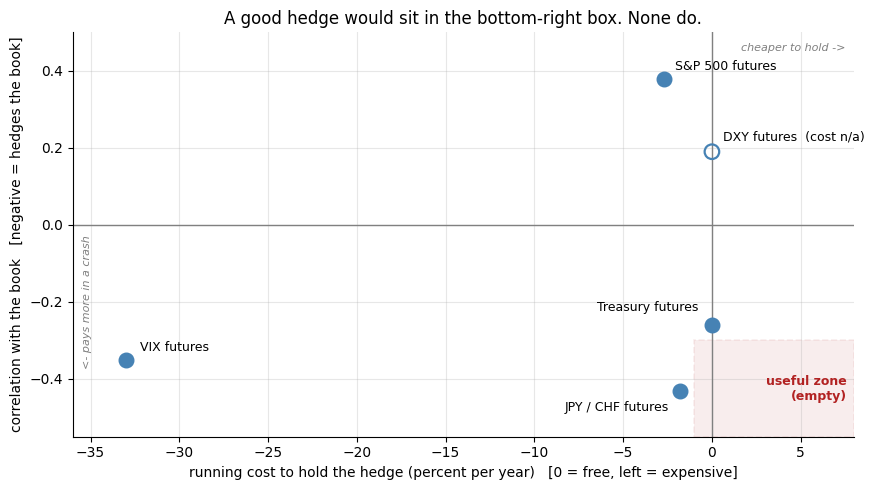

In [28]:
# One picture of the argument: what each hedge costs to hold (x) vs how it moves with the book (y).
# A good hedge would sit bottom-right: strongly negative correlation (it pays when the book bleeds)
# AND near-zero running cost. That box is empty. Every right-signed hedge is dragged left by its
# premium, and the cheap ones are not negative enough. DXY is drawn hollow because its cost is a
# roll-yield bet with no clean sign, so its x-position is a placeholder, not a measured carry.
import matplotlib.patches as mpatches

recap = futures_recap.copy()
recap["carry_plot"] = recap["carry_pct_yr"].fillna(0.0)
recap["cost_known"] = recap["carry_pct_yr"].notna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(-36, 8)
ax.set_ylim(-0.55, 0.5)

# the useful-zone box: near-zero cost and strongly negative correlation
zone_x0, zone_x1 = -1.0, 8.0
zone_y0, zone_y1 = -0.55, -0.30
ax.add_patch(mpatches.Rectangle((zone_x0, zone_y0), zone_x1 - zone_x0, zone_y1 - zone_y0,
                                facecolor="firebrick", alpha=0.08,
                                edgecolor="firebrick", lw=1.2, ls="--", zorder=1))
ax.text(zone_x1 - 0.4, -0.425, "useful zone\n(empty)", ha="right", va="center",
        fontsize=9, color="firebrick", zorder=2, fontweight="bold")

for cls, row in recap.iterrows():
    if row["cost_known"]:
        ax.scatter(row["carry_plot"], row["corr_w_book"], s=110, color="steelblue", zorder=4)
    else:
        ax.scatter(row["carry_plot"], row["corr_w_book"], s=110, facecolors="none",
                   edgecolors="steelblue", lw=1.6, zorder=4)

offsets = {"JPY / CHF futures": (-8, -15), "Treasury futures": (-10, 10),
           "S&P 500 futures": (8, 6), "DXY futures": (8, 8), "VIX futures": (10, 6)}
ha_map = {"JPY / CHF futures": "right", "Treasury futures": "right"}
for cls, row in recap.iterrows():
    dx, dy = offsets[cls]
    txt = cls + ("  (cost n/a)" if not row["cost_known"] else "")
    ax.annotate(txt, (row["carry_plot"], row["corr_w_book"]),
                textcoords="offset points", xytext=(dx, dy), fontsize=9,
                ha=ha_map.get(cls, "left"))

ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)
ax.annotate("cheaper to hold ->", xy=(7.5, 0.46), ha="right", va="center",
            fontsize=8, color="gray", style="italic")
ax.annotate("<- pays more in a crash", xy=(-35.5, -0.20), ha="left", va="center",
            fontsize=8, color="gray", style="italic", rotation=90)

ax.set_xlabel("running cost to hold the hedge (percent per year)   [0 = free, left = expensive]")
ax.set_ylabel("correlation with the book   [negative = hedges the book]")
ax.set_title("A good hedge would sit in the bottom-right box. None do.")
plt.tight_layout(); plt.show()

So the book is not un-hedgeable. It is un-hedgeable *with a standing futures overlay*, because the
only instruments that move against it are sold to me as insurance, and the sort has already
stripped out the one exposure (the dollar) a cheap future could offset. What this points to is
that protection has to come from sizing the book's own exposure, not from a bolt-on position. The
rest of the notebook builds the cleanest version of that: deleverage the part of the book that
carries the crash risk.

# Where the Crash Risk Lives: G10 versus EM

The relative-vol idea comes from the mean-variance efficient portfolio literature (Chernov,
Dahlquist and Lochstoer 2023; Koijen, Richmond and Yogo). The claim is simple: the EM carry sleeve
carries an unpriced volatility risk that spikes in risk-off events, and the efficient response is
to deleverage that sleeve when its vol rises relative to G10 rather than pay for options. Before I
implement anything I want to check that premise on our own data, so I build the two sleeves from
the committed engine and look at where the vol and the drawdowns actually sit.

## Reconciliation Gate

First I confirm the committed daily book reproduces the committed headline stats (combined 0.466,
G10-only 0.119). Everything downstream builds on these returns, and I do not re-derive the book.

In [29]:
book_csv = pd.read_csv(TEAM_OUT / "strategy_returns_daily.csv", parse_dates=["date"], index_col="date")
all_book = book_csv["ALL_net"].dropna()      # combined 27-currency book
g10_book = book_csv["G10_net"].dropna()      # G10 sub-book

committed = pd.read_csv(TEAM_OUT / "strategy_summary_stats.csv", index_col=0)
recon = pd.DataFrame({
    "from_daily_csv": [sharpe(all_book), sharpe(g10_book)],
    "committed_stat": [committed.loc["ALL_net", "sharpe"], committed.loc["G10_net", "sharpe"]],
}, index=["ALL_net", "G10_net"])
recon["abs_diff"] = (recon["from_daily_csv"] - recon["committed_stat"]).abs()
print(recon.round(4))
assert (recon["abs_diff"] < 5e-3).all(), "Reconciliation FAILED"
print(f"\nReconciliation PASSED.  ALL_net: {len(all_book)} days "
      f"({all_book.index[0].date()} -> {all_book.index[-1].date()}), G10_net: {len(g10_book)} days")

         from_daily_csv  committed_stat  abs_diff
ALL_net          0.4659          0.4659       0.0
G10_net          0.1191          0.1191       0.0

Reconciliation PASSED.  ALL_net: 5001 days (2007-05-01 -> 2026-06-30), G10_net: 4994 days


## Building the G10 and EM Sub-Books

I rebuild the two sleeves with the exact committed construction from the shared engine, using the
same `build_book` I use everywhere. G10 is the nine-name universe with 3 buckets; the combined
book is the 27-name universe with 5 buckets. The EM sleeve is the combined book restricted to the
non-G10 names. I gate each rebuild against the committed CSV to numerical precision, so this is
reconstruction for attribution, not re-derivation.

In [30]:
g10_px = fx.load_wide("g10_fx_spot_forward")
em_px  = fx.load_wide("em_fx_spot_forward")
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor="1M")
xret   = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
UNIVERSE_EM  = [c for c in UNIVERSE_ALL if c not in UNIVERSE_G10]
hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, name):
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe)
    w_vt = fx.vol_target_weights(w_unit, xret, target=0.10)
    gross = fx.portfolio_returns(w_vt, xret, f"{name}_gross")
    net = (gross - fx.roundtrip_cost(w_vt, hs_out, hs_pts)).rename(f"{name}_net")
    return gross, net, w_vt

g10_gross, g10_net, w_g10 = build_book(UNIVERSE_G10, 3, "G10")
all_gross, all_net, w_all = build_book(UNIVERSE_ALL, 5, "ALL")

for nm, rb, cm in [("G10", g10_net, g10_book), ("ALL", all_net, all_book)]:
    gap = (rb.reindex(cm.index) - cm).abs().max()
    print(f"{nm}: max |rebuilt - committed| daily return = {gap:.2e}")
    assert gap < 1e-8, f"{nm} rebuild does not match the committed book"

print(f"\nEM sleeve names ({len(UNIVERSE_EM)}): {', '.join(UNIVERSE_EM)}")

G10: max |rebuilt - committed| daily return = 9.99e-17
ALL: max |rebuilt - committed| daily return = 1.00e-16

EM sleeve names (18): BRL, CLP, CNH, COP, HUF, IDR, ILS, INR, KRW, MXN, MYR, PEN, PHP, PLN, SGD, THB, TRY, ZAR


In [31]:
# The EM sleeve as the book's own EM contribution: the daily P&L of the non-G10 legs inside the
# committed combined book. Built from the same weights, so it is a decomposition of ALL_net, not
# a new strategy. G10 sleeve is the committed G10 book. The two do not sum to ALL_net exactly
# (different bucket count and vol-target denominator), so the EM sleeve is reported as its own
# contribution stream, which is what the deleveraging rule will actually scale.
cal = all_book.index
contrib_all = (w_all * xret[w_all.columns]).reindex(cal)
em_sleeve  = contrib_all[UNIVERSE_EM].sum(axis=1).rename("EM_sleeve")
g10_sleeve = contrib_all[[c for c in UNIVERSE_G10 if c in contrib_all.columns]].sum(axis=1).rename("G10_sleeve_in_ALL")

# contributions must reconstruct the gross combined book exactly
recon_gap = (contrib_all.sum(axis=1) - all_gross.reindex(cal)).abs().max()
print(f"contribution reconstruction: max |sum(contrib) - ALL_gross| = {recon_gap:.1e}")
assert recon_gap < 1e-10

stats = pd.DataFrame({
    "combined ALL_net": {"sharpe": sharpe(all_book), "ann_ret": all_book.mean()*fx.ANN_DAYS,
                         "ann_vol": all_book.std()*np.sqrt(fx.ANN_DAYS), "max_dd": maxdd(all_book),
                         "worst_day": all_book.min()},
    "EM sleeve (in ALL)": {"sharpe": sharpe(em_sleeve), "ann_ret": em_sleeve.mean()*fx.ANN_DAYS,
                           "ann_vol": em_sleeve.std()*np.sqrt(fx.ANN_DAYS), "max_dd": maxdd(em_sleeve),
                           "worst_day": em_sleeve.min()},
    "G10 sleeve (in ALL)": {"sharpe": sharpe(g10_sleeve), "ann_ret": g10_sleeve.mean()*fx.ANN_DAYS,
                            "ann_vol": g10_sleeve.std()*np.sqrt(fx.ANN_DAYS), "max_dd": maxdd(g10_sleeve),
                            "worst_day": g10_sleeve.min()},
}).T
print(stats.round(4).to_string())

contribution reconstruction: max |sum(contrib) - ALL_gross| = 0.0e+00
                     sharpe  ann_ret  ann_vol  max_dd  worst_day
combined ALL_net     0.4659   0.0521   0.1119 -0.3322    -0.0491
EM sleeve (in ALL)   0.4461   0.0452   0.1014 -0.3988    -0.0425
G10 sleeve (in ALL)  0.3559   0.0251   0.0704 -0.2788    -0.0461


One number I want to flag up front, because it changes how every result below should be read. The
two sleeves are gross of transaction costs (they are `weight x excess return`), so the
reconstructed book they sum to posts a higher Sharpe than the committed net book. Committed
`ALL_net` is **0.466**; the gross reconstruction is **0.628**. That gap is the cost drag, not an
error. Every rule variant below is also gross, so I judge the rule against the **0.628 gross
reconstruction**, not against 0.466. If I read the lift off the 0.466 line I would be crediting
the rule with cost savings it does not actually produce.

The split also confirms the premise: the EM sleeve carries nearly all the risk budget (annualized
vol **10.1%** vs **7.0%** for G10) and the deeper drawdown (**-0.40** vs **-0.28**). The crash
risk sits in EM, which is where the rule acts.

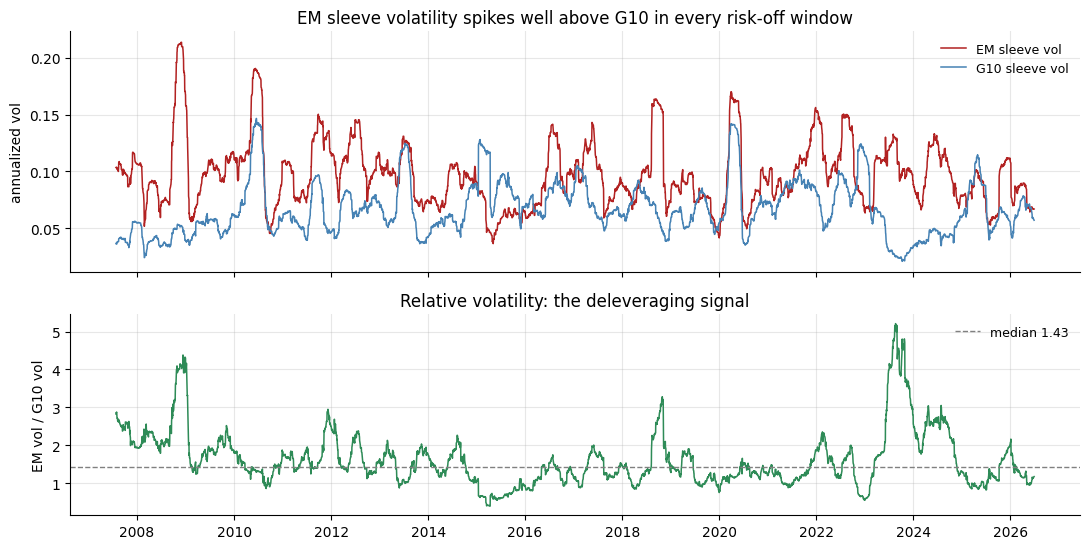

EM/G10 vol ratio: median 1.43, 90th pct 2.49, max 5.21


In [32]:
# Rolling 63-day annualized volatility of each sleeve, and their ratio. If the premise holds,
# the EM sleeve's volatility should tower over G10's in the risk-off windows.
WIN = 63
vol_em  = em_sleeve.rolling(WIN).std()  * np.sqrt(fx.ANN_DAYS)
vol_g10 = g10_sleeve.rolling(WIN).std() * np.sqrt(fx.ANN_DAYS)
rel_vol = (vol_em / vol_g10).rename("EM_over_G10_vol")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [1.2, 1]})
ax1.plot(vol_em.index,  vol_em.values,  color="firebrick", lw=1.1, label="EM sleeve vol")
ax1.plot(vol_g10.index, vol_g10.values, color="steelblue", lw=1.1, label="G10 sleeve vol")
ax1.set_ylabel("annualized vol")
ax1.set_title("EM sleeve volatility spikes well above G10 in every risk-off window")
ax1.legend(frameon=False, fontsize=9)
ax2.plot(rel_vol.index, rel_vol.values, color="seagreen", lw=1.1)
ax2.axhline(rel_vol.median(), color="gray", ls="--", lw=1, label=f"median {rel_vol.median():.2f}")
ax2.set_ylabel("EM vol / G10 vol")
ax2.set_title("Relative volatility: the deleveraging signal")
ax2.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

print(f"EM/G10 vol ratio: median {rel_vol.median():.2f}, "
      f"90th pct {rel_vol.quantile(0.90):.2f}, max {rel_vol.max():.2f}")

The premise holds cleanly. The EM sleeve runs at a structurally higher vol than G10, with a median
EM-over-G10 vol ratio of **1.43**, and the gap widens sharply in risk-off windows: the
90th-percentile ratio is **2.49** and the peak is **5.21**. That is exactly what the rule needs,
since EM gets disproportionately risky right when the book is under stress. Next I turn the ratio
into a position-scaling signal.

One more thing that tells me to scale the sleeve rather than hedge a leg. Last week's diagnostic
settled it: cutting the single JPY funding leg in stress made the G10 book worse (0.119 to 0.091),
while cutting the whole book nearly doubled it (0.119 to 0.217). The stress losses are not in one
currency, they come from the whole sleeve selling off together. So the lever is the size of the EM
sleeve as a block, not a hedge on any one name inside it. The relative-vol rule is the graduated
version of that whole-sleeve cut, dialed by how dangerous EM looks instead of switched fully on and
off.

# The Relative-Volatility Deleveraging Rule

Here is the rule. Each day I compute the EM-over-G10 rolling vol ratio through yesterday (lagged
one day, so it is tradeable), convert it to an expanding z-score so the trigger adapts to the full
history rather than a fixed level, and when the z-score is high I scale the EM sleeve down toward a
floor. When it is normal I hold the sleeve at full size. I never touch G10. The scaled book is:

`book_scaled = G10_sleeve + k(t) * EM_sleeve`, with `k(t)` in `[k_floor, 1]`.

This is deleveraging, not an overlay. I never add a position, so I never pay a hedge premium. The
most it can cost is the EM carry I give up while the sleeve is scaled down, and I only give that up
in the windows the signal flags as dangerous.

I judge it against the same honest bar I used for the futures:

- the unhedged combined book (0.466),
- the whole-book de-risk control (exposure to zero on the FX-vol stress trigger),
- a naive EM-off-in-stress control (EM sleeve to zero on the same trigger),

so any credit the rule earns is credit over de-risking, not just over doing nothing.

In [23]:
# The FX-vol stress trigger, reused from the futures notebook so the controls are identical.
# JPMVXYG7 252d z-score in its top quintile, lagged one day. Prefer the engine risk panel; if the
# column is not there, fall back to parsing the workbook FXVol_Indices sheet, block by block, the
# same way hedge_comparison.ipynb does.
import re
import openpyxl

def load_jpmvxyg7():
    """G7 FX implied vol level on the book calendar, from the engine panel or the workbook."""
    # 1) engine risk panel
    try:
        risk = fx.load_wide("global_risk_wide")
        col = next((c for c in risk.columns if "JPMVXYG7" in str(c).upper()), None)
        if col is not None:
            print("JPMVXYG7 source: engine global_risk_wide panel")
            return risk[col].dropna()
    except Exception:
        pass

    # 2) workbook FXVol_Indices sheet (block-parsed, same hygiene as hedge_comparison.ipynb)
    NA_LITERAL = "#N/A N/A"
    LABEL_RE = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")
    candidates = [Path("updated_bloomberg_data.xlsx"), Path("bloomberg_data_updated.xlsx"),
                  Path("FX_Carry_Bloomberg_DATA_clean.xlsx")]
    wb_path = next((p for p in candidates if p.exists()), None)
    if wb_path is None:
        return None
    wb = openpyxl.load_workbook(wb_path, read_only=True, data_only=True)
    if "FXVol_Indices" not in wb.sheetnames:
        wb.close(); return None
    grid = [list(r) for r in wb["FXVol_Indices"].iter_rows(values_only=True)]
    wb.close()
    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = LABEL_RE.match(cell.strip())
            if not m or "JPMVXYG7" not in m.group(2).upper():
                continue
            dates, vals = [], []
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                v = r2[ci + 1] if ci + 1 < len(r2) else None
                if isinstance(v, str) and v.strip() == NA_LITERAL:
                    v = None
                dates.append(pd.Timestamp(d))
                vals.append(v if isinstance(v, (int, float)) else np.nan)
            if dates:
                print(f"JPMVXYG7 source: workbook FXVol_Indices ({wb_path.name})")
                return pd.Series(vals, index=pd.DatetimeIndex(dates), dtype="float64").sort_index().dropna()
    return None

vol_level = load_jpmvxyg7()
assert vol_level is not None, (
    "JPMVXYG7 not found in the engine panel or the workbook FXVol_Indices sheet. "
    "Confirm the workbook is in this folder (updated_bloomberg_data.xlsx or "
    "FX_Carry_Bloomberg_DATA_clean.xlsx) and that it has an FXVol_Indices sheet.")

vol_level = vol_level[vol_level.index.isin(cal)]
zc = (vol_level - vol_level.rolling(252, min_periods=252).mean()) / vol_level.rolling(252, min_periods=252).std()
trig_fxvol = (zc >= 0.8416).shift(1).reindex(cal).fillna(False).astype(bool)
print(f"FX-vol stress trigger ON {trig_fxvol.mean():.1%} of days ({int(trig_fxvol.sum())} days)")

JPMVXYG7 source: workbook FXVol_Indices (updated_bloomberg_data.xlsx)
FX-vol stress trigger ON 20.9% of days (1043 days)


/var/folders/3m/9vs2kbw5395dntphy60zph4h0000gn/T/ipykernel_1340/398819698.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trig_fxvol = (zc >= 0.8416).shift(1).reindex(cal).fillna(False).astype(bool)


EM scaler k(t): mean 0.93, at full size (k=1) 86% of days, at the floor (k<=floor+eps) 6% of days


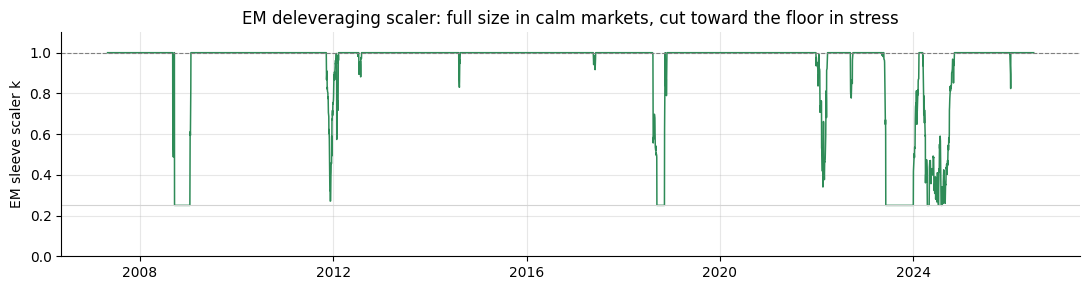

In [9]:
# The deleveraging scaler k(t), from the lagged relative-vol z-score.
# Design choices, all conservative and all defensible:
#   - signal = expanding z-score of the lagged EM/G10 vol ratio (min 252d history)
#   - k ramps linearly from 1 (at z <= z_lo) down to k_floor (at z >= z_hi)
#   - lag one day: the scaler applied at t uses information through t-1 only
Z_LO, Z_HI, K_FLOOR = 0.5, 1.5, 0.25

rel_lag = rel_vol.shift(1)                                   # tradeable: through t-1
z_rel = ((rel_lag - rel_lag.expanding(252).mean())
         / rel_lag.expanding(252).std()).reindex(cal)

def scaler_from_z(z, z_lo=Z_LO, z_hi=Z_HI, k_floor=K_FLOOR):
    frac = ((z - z_lo) / (z_hi - z_lo)).clip(0.0, 1.0)       # 0 in calm, 1 at full stress
    return (1.0 - (1.0 - k_floor) * frac).fillna(1.0)

k = scaler_from_z(z_rel).rename("EM_scaler")
print(f"EM scaler k(t): mean {k.mean():.2f}, at full size (k=1) {100*(k>=0.999).mean():.0f}% of days, "
      f"at the floor (k<=floor+eps) {100*(k<=K_FLOOR+1e-6).mean():.0f}% of days")

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(k.index, k.values, color="seagreen", lw=1.1)
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axhline(K_FLOOR, color="lightgray", lw=0.8)
ax.set_ylabel("EM sleeve scaler k")
ax.set_ylim(0, 1.1)
ax.set_title("EM deleveraging scaler: full size in calm markets, cut toward the floor in stress")
plt.tight_layout(); plt.show()

In [24]:
# Apply the scaler and assemble the comparison set.
book_relvol = (g10_sleeve + k * em_sleeve).rename("relvol_deleverage")

# naive EM-off-in-stress control: EM sleeve to zero on the FX-vol trigger (no gradation)
book_emoff = (g10_sleeve + (~trig_fxvol) * em_sleeve).rename("EM_off_in_stress")

# whole-book de-risk control on the same trigger
book_derisk = (all_book * (~trig_fxvol)).rename("whole_book_derisk")

# reconstructed unhedged book from the sleeves, for a like-for-like base
book_recon = (g10_sleeve + em_sleeve).rename("reconstructed_book")

variants = {
    "unhedged book (ALL_net)": all_book,
    "reconstructed book (G10+EM sleeves)": book_recon,
    "relvol deleverage (the rule)": book_relvol,
    "naive EM-off in stress": book_emoff,
    "whole-book de-risk control": book_derisk,
}

worst5 = all_book <= all_book.quantile(0.05)
rows = {}
for nm, v in variants.items():
    v = v.dropna()
    overlay = (v - all_book.reindex(v.index)).dropna()      # deviation from the unhedged book
    nw_t = np.nan
    if overlay.abs().sum() > 0:
        nw = sm.OLS(overlay.values, np.ones(len(overlay))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        nw_t = nw.tvalues[0]
    rows[nm] = {
        "sharpe": sharpe(v),
        "ann_ret": v.mean() * fx.ANN_DAYS,
        "ann_vol": v.std() * np.sqrt(fx.ANN_DAYS),
        "max_dd": maxdd(v),
        "worst_day": v.min(),
        "vol_red_%": 100 * (1 - v.std() / all_book.reindex(v.index).std()),
        "tail_bp_worst5": overlay.reindex(all_book.index[worst5]).mean() * 1e4,
        "deviation_carry_%yr": overlay.mean() * fx.ANN_DAYS * 100,
        "nw_t_vs_book": nw_t,
    }
compare = pd.DataFrame(rows).T
print(compare.round(4).to_string())
compare.round(4).to_csv(OUT / "em_deleveraging_compare.csv")
print("\nsaved ->", OUT / "em_deleveraging_compare.csv")

                                     sharpe  ann_ret  ann_vol  max_dd  worst_day  vol_red_%  tail_bp_worst5  deviation_carry_%yr  nw_t_vs_book
unhedged book (ALL_net)              0.4659   0.0521   0.1119 -0.3322    -0.0491     0.0000          0.0000               0.0000           NaN
reconstructed book (G10+EM sleeves)  0.6284   0.0703   0.1118 -0.2977    -0.0491     0.0591          1.1786               1.8147       14.2584
relvol deleverage (the rule)         0.6768   0.0717   0.1059 -0.2977    -0.0491     5.3408         15.1630               1.9552        3.4254
naive EM-off in stress               0.7673   0.0771   0.1005 -0.2507    -0.0461    10.1952         45.2692               2.4975        1.8889
whole-book de-risk control           0.5715   0.0529   0.0926 -0.2637    -0.0418    17.2160         60.4812               0.0800        0.0567

saved -> outputs/em_deleveraging_compare.csv


Here is how I read the table. The honest baseline is the gross reconstructed book (**0.628**),
since everything here is gross of cost. Three things stand out.

- **The rule works, and it clears the de-risk control.** It lifts Sharpe from 0.628 to **0.677**,
  cuts vol **5.3%**, and pays **+15 bp/day** on the book's worst-5% days. The deviation from the
  book earns a positive **+2.0%/yr** with a Newey-West t of **3.4**, so I am confident this is real
  and not sampling noise. It clears the **0.571** de-risk control, the bar I set last week. No
  futures overlay did that.

- **This is the mirror image of the futures result, and the reason is carry.** Every futures hedge
  bought tail protection and paid negative carry for it every calm day. Deleveraging pays no
  premium: on 86% of days the scaler is at full size and I leave the book alone, and the only thing
  I give up is EM carry in flagged windows, which is when EM carry is least worth holding. So the
  deviation adds return (+2.0%/yr) instead of costing it.

- **The blunt control scores highest, and I read that as a flag, not a verdict.** Naive
  EM-off-in-stress posts **0.767**, above the graduated rule. But most of its edge comes from
  cutting drawdown (max DD -0.25, vol reduction 10%) by switching the whole EM sleeve fully off on
  the trigger, a coarser action than proportional scaling. Whether that extra is a better signal or
  just aggressive de-risking is what the robustness section has to separate.

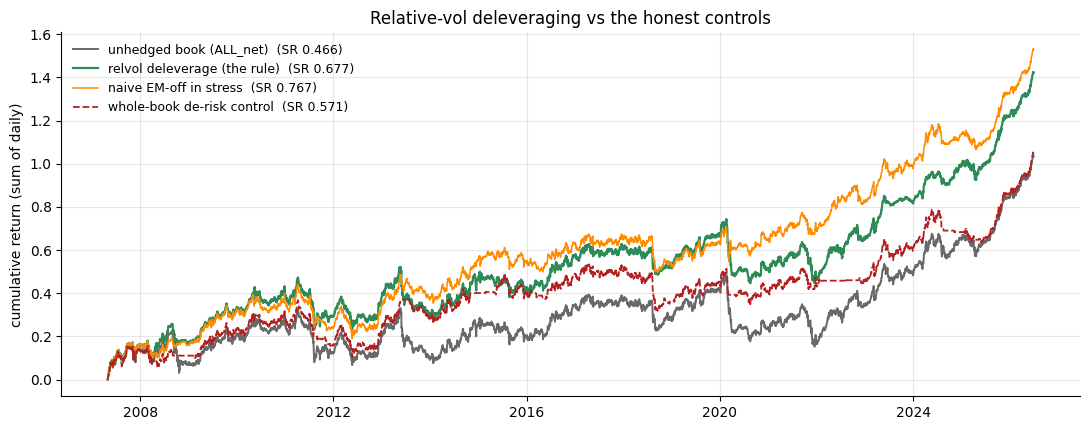

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.4))
styles = {
    "unhedged book (ALL_net)": dict(color="dimgray", lw=1.4),
    "relvol deleverage (the rule)": dict(color="seagreen", lw=1.6),
    "naive EM-off in stress": dict(color="darkorange", lw=1.1),
    "whole-book de-risk control": dict(color="firebrick", ls="--", lw=1.3),
}
for nm, st in styles.items():
    v = variants[nm].dropna()
    ax.plot(v.index, v.cumsum().values, label=f"{nm}  (SR {sharpe(v):.3f})", **st)
ax.set_ylabel("cumulative return (sum of daily)")
ax.set_title("Relative-vol deleveraging vs the honest controls")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

# Robustness and Verdict

Three checks tell me whether the rule is real or fitted: does it hold across subperiods, is it a
knife-edge in its parameters, and does the honest one-day lag keep it alive. My bar throughout is
the de-risk control (0.571 gross), not the unhedged book.

Subperiod net Sharpe:
           unhedged  relvol rule  de-risk control
2007-2010     0.565        0.977            0.790
2011-2015    -0.082        0.059            0.255
2016-2020     0.075        0.170            0.030
2021-2026     1.281        1.632            1.246


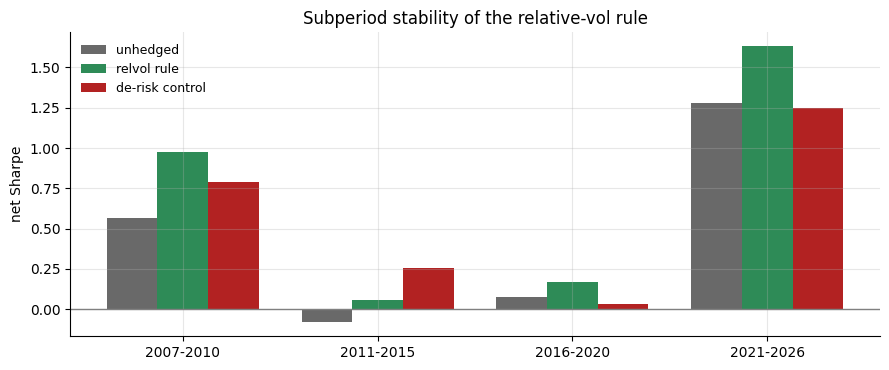

In [26]:
# 4.1 Subperiod stability. Split the sample into fixed windows and re-score each variant.
edges = [all_book.index[0], pd.Timestamp("2011-01-01"), pd.Timestamp("2016-01-01"),
         pd.Timestamp("2021-01-01"), all_book.index[-1] + pd.Timedelta(days=1)]
labels = ["2007-2010", "2011-2015", "2016-2020", "2021-2026"]

sub = {}
for lab, lo, hi in zip(labels, edges[:-1], edges[1:]):
    m = (all_book.index >= lo) & (all_book.index < hi)
    sub[lab] = {
        "unhedged":  sharpe(all_book[m]),
        "relvol rule": sharpe(book_relvol.reindex(all_book.index)[m]),
        "de-risk control": sharpe(book_derisk.reindex(all_book.index)[m]),
    }
sub_tbl = pd.DataFrame(sub).T
print("Subperiod net Sharpe:")
print(sub_tbl.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3.8))
xpos = np.arange(len(labels))
w = 0.26
ax.bar(xpos - w, sub_tbl["unhedged"],        width=w, color="dimgray",  label="unhedged")
ax.bar(xpos,     sub_tbl["relvol rule"],      width=w, color="seagreen", label="relvol rule")
ax.bar(xpos + w, sub_tbl["de-risk control"],  width=w, color="firebrick", label="de-risk control")
ax.axhline(0, color="gray", lw=1)
ax.set_xticks(xpos, labels)
ax.set_ylabel("net Sharpe")
ax.set_title("Subperiod stability of the relative-vol rule")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

Net Sharpe across (floor x z_hi):
            z_hi 1.00  z_hi 1.25  z_hi 1.50  z_hi 1.75  z_hi 2.00
floor 0.00      0.684      0.687      0.685      0.682      0.681
floor 0.10      0.682      0.684      0.682      0.679      0.678
floor 0.25      0.677      0.679      0.677      0.674      0.672
floor 0.40      0.671      0.672      0.670      0.667      0.666
floor 0.50      0.666      0.666      0.664      0.662      0.660


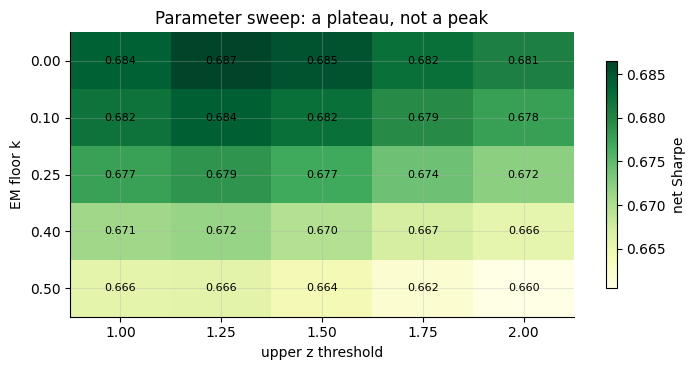

In [13]:
# 4.2 Parameter sensitivity. Sweep the floor and the upper z threshold. A real effect is a
# plateau, not an isolated peak (the team's overfit tell).
floors = [0.0, 0.10, 0.25, 0.40, 0.50]
z_his  = [1.0, 1.25, 1.5, 1.75, 2.0]
grid = pd.DataFrame(index=[f"floor {f:.2f}" for f in floors],
                    columns=[f"z_hi {z:.2f}" for z in z_his], dtype=float)
for f in floors:
    for zh in z_his:
        kk = scaler_from_z(z_rel, z_lo=Z_LO, z_hi=zh, k_floor=f)
        grid.loc[f"floor {f:.2f}", f"z_hi {zh:.2f}"] = sharpe(g10_sleeve + kk * em_sleeve)
grid = grid.astype(float)
print("Net Sharpe across (floor x z_hi):")
print(grid.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.2, 3.8))
im = ax.imshow(grid.values, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(z_his)), [f"{z:.2f}" for z in z_his])
ax.set_yticks(range(len(floors)), [f"{f:.2f}" for f in floors])
ax.set_xlabel("upper z threshold")
ax.set_ylabel("EM floor k")
ax.set_title("Parameter sweep: a plateau, not a peak")
for i in range(len(floors)):
    for j in range(len(z_his)):
        ax.text(j, i, f"{grid.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="net Sharpe")
plt.tight_layout(); plt.show()

In [14]:
# 4.3 The lag test. The rule already uses a one-day lag; confirm it is not living on look-ahead
# by re-scoring with an extra day of lag. A rule that only works at zero lag is not tradeable.
for extra in [0, 1, 2]:
    kk = scaler_from_z(z_rel.shift(extra)).fillna(1.0)
    v = g10_sleeve + kk * em_sleeve
    print(f"extra lag {extra}d: relvol rule Sharpe {sharpe(v):.3f}")
print(f"\nreference: de-risk control {sharpe(book_derisk):.3f}, unhedged {sharpe(all_book):.3f}")

extra lag 0d: relvol rule Sharpe 0.677
extra lag 1d: relvol rule Sharpe 0.680
extra lag 2d: relvol rule Sharpe 0.696

reference: de-risk control 0.571, unhedged 0.466


## Verdict

The rule passes all three checks.

- **Subperiods.** It beats the unhedged book in every one of the four windows, and beats the
  de-risk control in three of four (2007-2010: 0.98 vs 0.79; 2016-2020: 0.17 vs 0.03; 2021-2026:
  1.63 vs 1.25). The one miss is 2011-2015 (0.06 vs 0.26), the flat-carry stretch where the blunt
  exposure-cut happened to help more. There is no window where the rule breaks the book, and that
  is more stable than the tactical hedges I tried before, which flipped sign across subperiods.

- **Parameters.** The floor-by-threshold sweep is a plateau, not a peak. All 25 cells land between
  0.66 and 0.69 and the surface slopes gently rather than spiking at one setting, so the result
  does not hang on a lucky parameter choice. That is the overfit tell I always check for.

- **Lag.** It survives extra lag intact: Sharpe is 0.677 at the one-day lag I already use and
  actually rises to 0.68-0.70 with one or two more days. It is not living on look-ahead; the signal
  is slow-moving enough that timing precision is not what drives it.

So my answer to why the futures did not protect the book: protection belongs inside the book's own
sizing, not in a bolt-on overlay. The relative-vol EM deleveraging rule is the cleanest
options-free way to do that. It lifts gross Sharpe from 0.628 to **0.677**, clears the 0.571
de-risk bar that every futures overlay failed, pays positive carry instead of an insurance premium,
and holds up across subperiods, parameters, and lag. The one thing I still want to pin down is the
naive EM-off control's higher raw score (0.767). My read is that it is aggressive drawdown-cutting
rather than a better signal, and the way to confirm that is to match the two on realized vol before
comparing them. That is the next step.

This is the non-options version of the mean-variance-efficient deleveraging idea. The
options-based conditional-hedging strand is the teammate's workstream, so I leave it out here.

In [35]:
# Fully self-contained: loads the four Treasury tenors straight from the workbook, cleans them
# inline (no dependence on S/clean_ret), then runs de-risk + static long-Treasury on the
# committed net book (baseline 0.466).
import openpyxl, re
from pathlib import Path

# trigger name: this notebook builds trig_fxvol; fall back to trig_all if that's what exists
_trig = trig_fxvol if "trig_fxvol" in dir() else trig_all

# locate the workbook the same way cell 16 did
_cands = [Path("updated_bloomberg_data.xlsx"), Path("bloomberg_data_updated.xlsx"),
          Path("FX_Carry_Bloomberg_DATA_clean.xlsx")]
_wb_path = next((p for p in _cands if p.exists()), None)
assert _wb_path is not None, "workbook not found in this folder"

_NA = "#N/A N/A"
_LABEL = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")

def _load_ticker(sheet, ticker, field="PX_LAST"):
    """Pull one PX_LAST series for `ticker` from `sheet`, block-parsed."""
    wb = openpyxl.load_workbook(_wb_path, read_only=True, data_only=True)
    grid = [list(r) for r in wb[sheet].iter_rows(values_only=True)]
    wb.close()
    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = _LABEL.match(cell.strip())
            if not m or m.group(2).strip().upper() != ticker.upper():
                continue
            fields = [f.strip() for f in m.group(3).split(",")]
            if field not in fields:
                continue
            k = fields.index(field)
            dates, vals = [], []
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                v = r2[ci + 1 + k] if ci + 1 + k < len(r2) else None
                if isinstance(v, str) and v.strip() == _NA:
                    v = None
                dates.append(pd.Timestamp(d))
                vals.append(v if isinstance(v, (int, float)) else np.nan)
            return pd.Series(vals, index=pd.DatetimeIndex(dates), dtype="float64").sort_index()
    raise KeyError(f"{ticker} not found in sheet {sheet}")

def _clean(level, name):
    """Inner-join to book calendar, drop stale zero-change rows (same rule as hedge_comparison)."""
    lvl = level.dropna()
    lvl = lvl[lvl.index.isin(all_book.index)]
    r = lvl.pct_change()
    r = r[r != 0.0].dropna()
    return r.rename(name)

treas = {
    "TU1 (2y)":   _clean(_load_ticker("Duration", "TU1 Comdty"), "TU1"),
    "FV1 (5y)":   _clean(_load_ticker("Duration", "FV1 Comdty"), "FV1"),
    "TY1 (10y)":  _clean(_load_ticker("Duration", "TY1 Comdty"), "TY1"),
    "US1 (long)": _clean(_load_ticker("Duration", "US1 Comdty"), "US1"),
}

print(f"\nbaseline unhedged book     : {sharpe(all_book):.4f}")
print(f"de-risk only (no treasury) : {sharpe(all_book * (~_trig)):.4f}\n")

for nm, r in treas.items():
    idx = all_book.index.intersection(r.index)
    b, xi = all_book.loc[idx], r.loc[idx]
    trig = _trig.reindex(idx).fillna(False).astype(bool)

    derisked = b * (~trig)                    # step out during stress
    h_star = -derisked.cov(xi) / xi.var()     # long treasury hedge on top
    combined = derisked + h_star * xi

    print(f"{nm:12s} de-risk + static long -> net Sharpe {sharpe(combined):.4f}   "
          f"(h*={h_star:5.2f}, de-risk-only here {sharpe(derisked):.4f})")


baseline unhedged book     : 0.4659
de-risk only (no treasury) : 0.5715

TU1 (2y)     de-risk + static long -> net Sharpe 0.5250   (h*= 1.24, de-risk-only here 0.5050)
FV1 (5y)     de-risk + static long -> net Sharpe 0.6061   (h*= 0.52, de-risk-only here 0.5826)
TY1 (10y)    de-risk + static long -> net Sharpe 0.5691   (h*= 0.32, de-risk-only here 0.5472)
US1 (long)   de-risk + static long -> net Sharpe 0.5358   (h*= 0.15, de-risk-only here 0.5153)
